#CATS vs DOGS - CNN IMAGE CLASSIFIER

#Problem Statement:
The task at hand involves classifying images of cats and dogs using a Convolutional Neural Network (CNN). We have a dataset containing images of cats and dogs and the objective is to train a CNN model to accurately predict the class of each image.

#Objectives:

##Data Preparation:
● Download and extract the cats vs. dogs dataset.

● Organize the dataset into a structured directory format suitable for TensorFlow’s ImageDataGenerator.

● Split the dataset into training and testing sets.

##Data Augmentation and Preprocessing:
● Implement data augmentation techniques to increase the diversity of the training dataset, aiding in the model's ability to generalize.

● Normalize the pixel values of the images for optimal model performance.

##Model Building:
● Construct a Convolutional Neural Network using TensorFlow and Keras.

● Themodel should contain multiple convolutional layers, pooling layers, and fully connected layers.

##Training:
● Compile the model and train it on the prepared dataset.

● Utilize categorical cross entropy as the loss function and stochastic gradient descent as the optimizer.

● Train the model for a sufficient number of epochs to achieve good performance.

##Evaluation:
● Evaluate the model's performance on the validation set during training to monitor for overfitting.

● After training, assess the model's accuracy and make predictions on the test set.

##Prediction:
● Implement a system to make predictions on new images, categorizing them as either cat or dog.

● The system should be able to take an image (or a batch of images), preprocess it, and pass it through the model for prediction.

#IMPORTING LIBRARIES

In [1]:
import os
import shutil
import random
import zipfile
import urllib.request

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

#DOWNLOAD & ORGANIZE THE DATASET

In [2]:
DATASET_URL  = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
ZIP_PATH     = "cats_dogs.zip"
EXTRACT_DIR  = "PetImages"          # folder inside the zip
BASE_DIR     = "dataset"            # our organised dataset root

In [3]:
TRAIN_DIR    = os.path.join(BASE_DIR, "train")
TEST_DIR     = os.path.join(BASE_DIR, "test")
CATEGORIES   = ["Cat", "Dog"]

IMG_SIZE     = (150, 150)
BATCH_SIZE   = 32
EPOCHS       = 15
SPLIT_RATIO  = 0.8                  # 80 % train, 20 % test

In [4]:
def download_dataset():
    """Download the Microsoft Cats & Dogs dataset."""
    if not os.path.exists(ZIP_PATH):
        print("Downloading dataset (approx 800 MB) …")
        urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
        print("Download complete.")
    else:
        print("Zip already present – skipping download.")

In [5]:
def extract_dataset():
    """Unzip the dataset."""
    if not os.path.exists(EXTRACT_DIR):
        print("Extracting …")
        with zipfile.ZipFile(ZIP_PATH, "r") as z:
            z.extractall(".")
        print("Extraction complete.")
    else:
        print("Already extracted – skipping.")

In [6]:
def organize_dataset():
    """
    Split raw images into:
        dataset/train/Cat   dataset/train/Dog
        dataset/test/Cat    dataset/test/Dog
    Corrupted / unreadable images are automatically skipped.
    """
    if os.path.exists(BASE_DIR):
        print("Organised dataset already exists – skipping split.")
        return

    print("Organising dataset …")
    for split in ["train", "test"]:
        for cat in CATEGORIES:
            os.makedirs(os.path.join(BASE_DIR, split, cat), exist_ok=True)

    for category in CATEGORIES:
        src_folder = os.path.join(EXTRACT_DIR, category)
        images = [
            f for f in os.listdir(src_folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        random.shuffle(images)

        split_idx   = int(len(images) * SPLIT_RATIO)
        train_imgs  = images[:split_idx]
        test_imgs   = images[split_idx:]

        for fname in train_imgs:
            src  = os.path.join(src_folder, fname)
            dst  = os.path.join(TRAIN_DIR, category, fname)
            try:
                img = load_img(src)          # raises if file is corrupt
                shutil.copy(src, dst)
            except Exception:
                pass                         # skip corrupt files

        for fname in test_imgs:
            src  = os.path.join(src_folder, fname)
            dst  = os.path.join(TEST_DIR, category, fname)
            try:
                img = load_img(src)
                shutil.copy(src, dst)
            except Exception:
                pass

    print("Dataset organised.")

#DATA AUGMENTATION & PREPROCESSING

In [7]:
def create_data_generators():
    """
    Training  → augmentation + normalisation
    Testing   → normalisation only  (no augmentation on test data)
    """
    train_datagen = ImageDataGenerator(
        rescale            = 1.0 / 255,   # normalise pixels to [0, 1]
        rotation_range     = 20,
        width_shift_range  = 0.2,
        height_shift_range = 0.2,
        shear_range        = 0.2,
        zoom_range         = 0.2,
        horizontal_flip    = True,
        fill_mode          = "nearest"
    )

    test_datagen = ImageDataGenerator(rescale=1.0 / 255)

    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical"   # one-hot labels  [Cat, Dog]
    )

    test_gen = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size = IMG_SIZE,
        batch_size  = BATCH_SIZE,
        class_mode  = "categorical",
        shuffle     = False           # keep order for evaluation
    )

    return train_gen, test_gen

#BUILD THE CNN MODEL

In [8]:
def build_model():
    """
    Simple CNN:
        3 × (Conv2D → MaxPooling)
        Flatten → Dense(128) → Dropout → Dense(2, softmax)
    """
    model = models.Sequential([

        # ── Block 1 ──────────────────────────────────────────
        layers.Conv2D(32, (3, 3), activation="relu",
                      input_shape=(*IMG_SIZE, 3)),
        layers.MaxPooling2D(2, 2),

        # ── Block 2 ──────────────────────────────────────────
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),

        # ── Block 3 ──────────────────────────────────────────
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D(2, 2),

        # ── Fully Connected Head ──────────────────────────────
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),                # reduces overfitting
        layers.Dense(2, activation="softmax")  # Cat or Dog
    ])

    model.summary()
    return model

#COMPILE & TRAIN

In [9]:
def compile_and_train(model, train_gen, test_gen):
    model.compile(
        optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
        loss      = "categorical_crossentropy",
        metrics   = ["accuracy"]
    )

    history = model.fit(
        train_gen,
        epochs          = EPOCHS,
        validation_data = test_gen
    )

    return history

#EVALUATE & PLOT RESULTS

In [10]:
def evaluate_model(model, test_gen):
    loss, accuracy = model.evaluate(test_gen)
    print(f"\nTest  Loss    : {loss:.4f}")
    print(f"Test  Accuracy: {accuracy * 100:.2f} %")
    return loss, accuracy

In [11]:
def plot_history(history):
    """Plot training vs validation accuracy and loss."""
    acc      = history.history["accuracy"]
    val_acc  = history.history["val_accuracy"]
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs   = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val   Accuracy")
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     label="Train Loss")
    plt.plot(epochs, val_loss, label="Val   Loss")
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=120)
    plt.show()
    print("Plot saved as training_history.png")

#PREDICT ON A NEW IMAGE

In [12]:
def predict_image(model, image_path):
    """
    Pass a single image through the model and print the prediction.
    Returns  "Cat"  or  "Dog"  along with the confidence %.
    """
    CLASS_NAMES = ["Cat", "Dog"]

    img   = load_img(image_path, target_size=IMG_SIZE)
    arr   = img_to_array(img) / 255.0      # normalise
    arr   = np.expand_dims(arr, axis=0)    # add batch dimension → (1,150,150,3)

    preds = model.predict(arr)[0]          # shape: (2,)
    idx   = np.argmax(preds)
    label = CLASS_NAMES[idx]
    conf  = preds[idx] * 100

    print(f"\nPrediction : {label}  ({conf:.1f} % confidence)")

    # Show the image with the prediction title
    plt.imshow(img)
    plt.title(f"Predicted: {label}  ({conf:.1f}%)")
    plt.axis("off")
    plt.show()

    return label, conf

In [13]:
def predict_batch(model, folder_path):
    """Predict every image inside a folder and print a summary."""
    CLASS_NAMES = ["Cat", "Dog"]
    exts = (".jpg", ".jpeg", ".png")

    files = [f for f in os.listdir(folder_path) if f.lower().endswith(exts)]
    if not files:
        print("No images found in", folder_path)
        return

    print(f"\n{'Image':<30} {'Prediction':<10} {'Confidence':>10}")
    print("-" * 52)
    for fname in files:
        path  = os.path.join(folder_path, fname)
        img   = load_img(path, target_size=IMG_SIZE)
        arr   = img_to_array(img) / 255.0
        arr   = np.expand_dims(arr, axis=0)
        preds = model.predict(arr, verbose=0)[0]
        idx   = np.argmax(preds)
        print(f"{fname:<30} {CLASS_NAMES[idx]:<10} {preds[idx]*100:>9.1f}%")

run all steps in order

Download complete.
Extracting …
Extraction complete.
Organising dataset …


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dataset organised.
Found 19998 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.

Class indices: {'Cat': 0, 'Dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,610 (18.42 MB)

 Trainable params: 4,828,610 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 165s 256ms/step - accuracy: 0.5568 - loss: 0.6788 - val_accuracy: 0.5884 - val_loss: 0.6650
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 155s 247ms/step - accuracy: 0.5942 - loss: 0.6614 - val_accuracy: 0.6546 - val_loss: 0.6348
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 153s 245ms/step - accuracy: 0.6497 - loss: 0.6239 - val_accuracy: 0.7208 - val_loss: 0.5595
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 152s 244ms/step - accuracy: 0.6833 - loss: 0.5896 - val_accuracy: 0.7490 - val_loss: 0.5248
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 246ms/step - accuracy: 0.7034 - loss: 0.5691 - val_accuracy: 0.7602 - val_loss: 0.5063
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 156s 250ms/step - accuracy: 0.7099 - loss: 0.5566 - val_accuracy: 0.7688 - val_loss: 0.4913
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 153s 245ms/step - accuracy: 0.7324 - loss: 0.5370 - val_accuracy: 0.7792 - val_loss: 0.4730
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 153s 245ms/step - accuracy: 0.7344 -

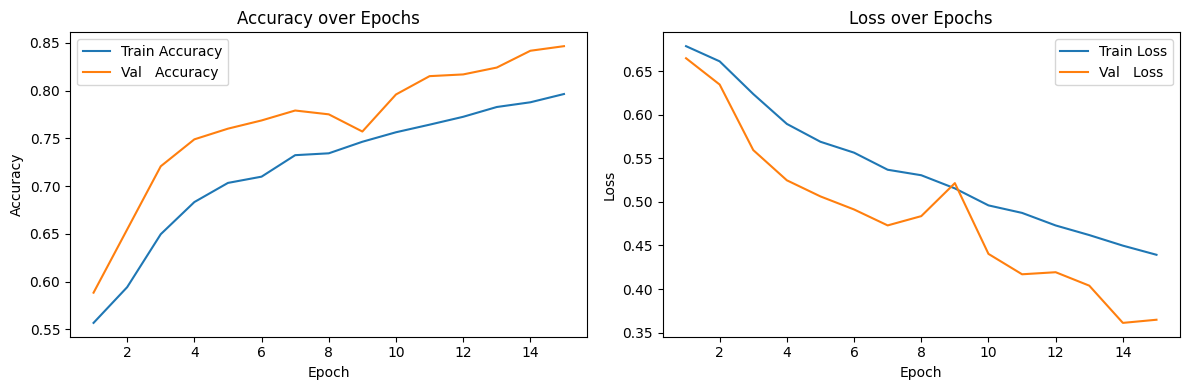

Plot saved as training_history.png

Model saved as  cats_dogs_model.keras


In [14]:
if __name__ == "__main__":

    # 1. Data
    download_dataset()
    extract_dataset()
    organize_dataset()

    # 2. Generators
    train_gen, test_gen = create_data_generators()
    print("\nClass indices:", train_gen.class_indices)   # {'Cat': 0, 'Dog': 1}

    # 3. Model
    model = build_model()

    # 4. Train
    history = compile_and_train(model, train_gen, test_gen)

    # 5. Evaluate
    evaluate_model(model, test_gen)
    plot_history(history)

    # 6. Save the model
    model.save("cats_dogs_model.keras")
    print("\nModel saved as  cats_dogs_model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Prediction : Cat  (69.6 % confidence)


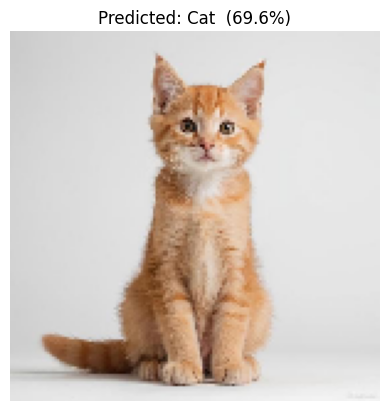

('Cat', np.float32(69.612686))

In [16]:
predict_image(model, "/content/sample image 1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Prediction : Dog  (99.7 % confidence)


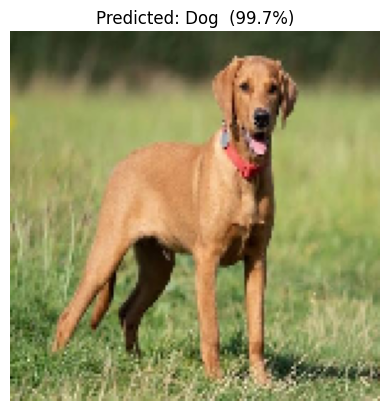

('Dog', np.float32(99.70323))

In [18]:
predict_image(model, "/content/sample image 2.jfif")